In [1]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")


Main.UniversalDiffEq

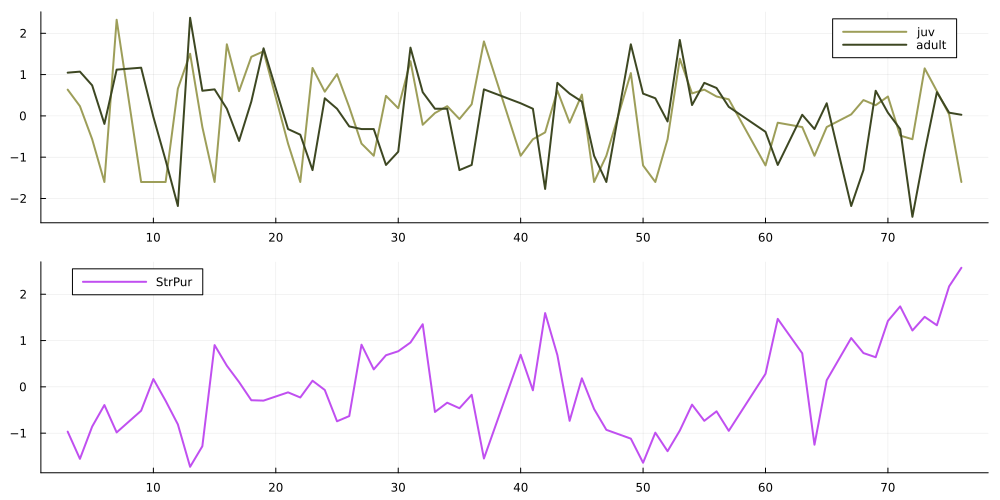

In [99]:
site = 4
dat = CSV.read("../data/processed_time_series.csv", DataFrame)[:,2:end]
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states

X = dat[dat.SITE .== site,[:PERIOD,:StrPur,:PycHel]]



p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
# Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
# Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
plot(p1,p2, layout = (2,1), size = (1000,500))

In [100]:
X[1:2,:]

Row,PERIOD,StrPur,PycHel
,Int64,Float64,Float64
1,3,-0.966806,-0.74234
2,4,-1.55477,-0.74234


In [101]:
covars = [1,2]

NN, NNparameters = UniversalDiffEq.SimpleNeuralNetwork(2+length(covars),2, hidden = 10, seed = 5491)

function dudt(u,X,p,t,covars)
    return NN(vcat(u,X[covars]), p.NN) # index 3 is pycnopodia  ,X[1:2]
end

init_parameters = (NN = NNparameters, )

NODE = UniversalDiffEq.CustomDerivatives(training,X,(u,X,p,t) -> dudt(u,X,p,t,covars),
                                            init_parameters;time_column_name = "PERIOD")

UniversalDiffEq.train!(NODE, loss_function = "spline gradient matching", 
        regularization_weight = 100, optim_options = (maxiter = 500, step_size = 0.025), 
        loss_options = (σ = 0.05, τ = 0.5, T = 2*size(training)[1]))
nothing

132
54719.172 52506.523 50409.529 48421.266 46535.583 44745.266 43041.955 41416.844 39862.041 38371.57 36941.322 35568.515 34251.198 32987.903 31777.463 30618.865 29511.109 28453.062 27443.369 26480.452 25562.534 24687.716 23854.063 23059.69 22302.814 21581.785 20895.077 20241.268 19619.007 19026.996 18463.98 17928.738 17420.075 16936.83 16477.883 16042.154 15628.594 15236.189 14863.959 14510.956 14176.276 13859.048 13558.434 13273.617 13003.807 12748.238 12506.176 12276.913 12059.769 11854.08 11659.212 11474.555 11299.532 11133.599 10976.246 10826.994 10685.404 10551.069 10423.612 10302.68 10187.932 10079.042 9975.691 9877.57 9784.38 9695.839 9611.68 9531.658 9455.545 9383.129 9314.212 9248.603 9186.113 9126.559 9069.765 9015.566 8963.81 8914.363 8867.105 8821.929 8778.73 8737.408 8697.863 8659.994 8623.707 8588.916 8555.541 8523.511 8492.76 8463.225 8434.846 8407.56 8381.308 8356.033 8331.679 8308.196 8285.535 8263.649 8242.49 8222.016 8202.184 8182.96 8164.311 8146.208 8128.623 8111

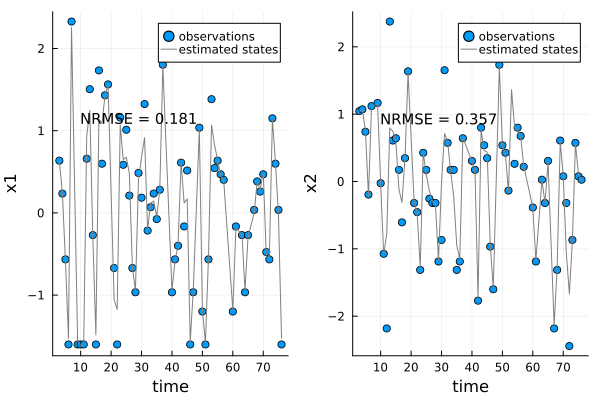

In [102]:
UniversalDiffEq.plot_state_estimates(NODE)

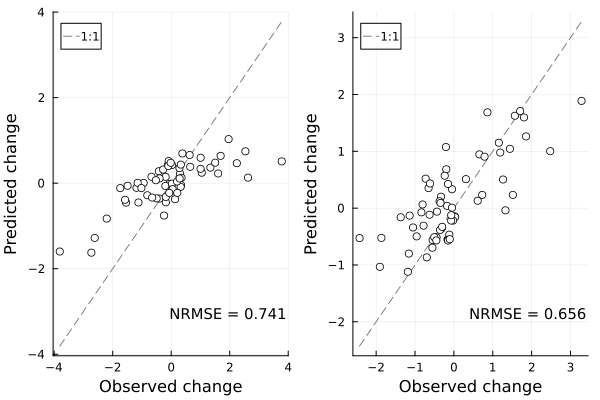

In [103]:
UniversalDiffEq.plot_predictions(NODE)

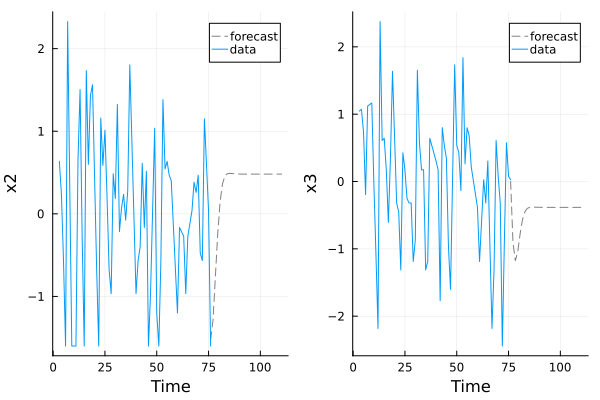

In [104]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(NODE, 30)
plt

In [107]:

using ForwardDiff


function transform_states(u,mean,scale)
    y = scale.*exp.(u).+mean
    return y
end


function percap_growth(y,mean,scale)
    u = log.((y.-mean)./scale)
    X = u[3:end]; u = u[1:2]
    dydu = scale[1:2].*exp.(u)
    dudt = rhs(u,X,0.0)
    return dydu.*dudt./y[1:2]
end 


function percap_growth_jacobian(y,mean,scale)
    f = y ->  percap_growth(y,mean,scale)
    return ForwardDiff.jacobian(f, y)
end 


function get_scaling_factors(site)
    scaling_factors  = CSV.read("../data/scaling_factors.csv", DataFrame)[:,2:end]
    scaling_factors = scaling_factors[scaling_factors.SITE.==site,:]
    Xinds = [4,6,2,3]
    mean = scaling_factors.mean[Xinds]
    scale = scaling_factors.sd[Xinds]
    return scale, mean
end

rhs = UniversalDiffEq.get_right_hand_side(NODE)

scale, means = get_scaling_factors(4)
obs = size(NODE.parameters.uhat)[2]
effects_juv = zeros(obs,4)
effects_adults = zeros(obs,4)
for i in 1:size(NODE.parameters.uhat)[2]
    u = vcat(NODE.parameters.uhat[:,i],Vector(NODE.X[i,2:end]))
    y = transform_states(u,means,scale)
    effects = percap_growth_jacobian(y,means,scale)
    effects_juv[i,:] = effects[1,:]
    effects_adults[i,:] = effects[2,:]
end 


In [138]:
p1 = Plots.plot(effects_juv[:,1], width = 3,  label = "Juviniles",c=5,linestyle=:dash)
Plots.plot!(effects_juv[:,2], width = 3,  label = "Adults",c=3)
Plots.plot!(effects_juv[:,3], width = 3, label = "Purple Urchins",c=4)
Plots.plot!(effects_juv[:,4], width = 3, label = "Pycnopodia",c=2)
Plots.plot!(tickfontsize=10, legendfontsize=10, guidefontsize=12,
            xlabel = "Time period",ylabel = "Interaction strength", size = (500,300),
            margin = 5mm,dpi=600) #title = "Effects on Juviniles"
savefig("~/documents/site4_effects_NODE_juv.png")

"/Users/johnbuckner/documents/site4_effects_NODE_juv.png"

In [139]:
p2 = Plots.plot(effects_adults[:,1], width = 3,  label = "Juviniles",c=5,linestyle=:dash)
Plots.plot!(effects_adults[:,2], width = 3,  label = "Adults",c=3)
Plots.plot!(effects_adults[:,3], width = 3, label = "Purple Urchins",c=4)
Plots.plot!(effects_adults[:,4], width = 3, label = "Pycnopodia",c=2)
Plots.plot!(tickfontsize=10, legendfontsize=10, guidefontsize=12,
            xlabel = "Time period",ylabel = "Interaction strength", size = (500,300),
            margin = 5mm,dpi=600) #title = "Effects on Juviniles"
savefig("~/documents/site4_effects_NODE_adult.png")

"/Users/johnbuckner/documents/site4_effects_NODE_adult.png"

In [117]:
adults_df = stack(DataFrame(effects_adults,[:Juv,:Adults,:Urchins,:Pyc]))
adults_df.outcome .= "Adults"
juv_df = stack(DataFrame(effects_juv,[:Juv,:Adults,:Urchins,:Pyc]))
juv_df.outcome .= "Adults"
effects_df = vcat(adults_df,juv_df)
effects_df[1:4,:]

Row,variable,value,outcome
,String,Float64,String
1,Juv,0.0984584,Adults
2,Juv,0.145097,Adults
3,Juv,0.184319,Adults
4,Juv,0.178563,Adults


In [136]:
using StatsPlots
p1_ = @df adults_df boxplot(:variable, :value, ylim = (-6,0.75),ylabel = "Interaction strength",
                        label = "",  color = "white", width = 2, title = "Adults (NODE)")
p2_ = @df juv_df boxplot(:variable, :value, ylim = (-6,0.75),label = "", 
                         color = "white", width = 2, title = "Juviniles (NODE)")
plot(p1_,p2_)
p3 = Plots.plot!(tickfontsize=10, legendfontsize=8, guidefontsize=12,titlefontsize=12,
            xlabel = "Varaible", size = (600,250), margin = 5mm,dpi=600)
savefig("~/documents/site4_effects_box.png")

"/Users/johnbuckner/documents/site4_effects_box.png"

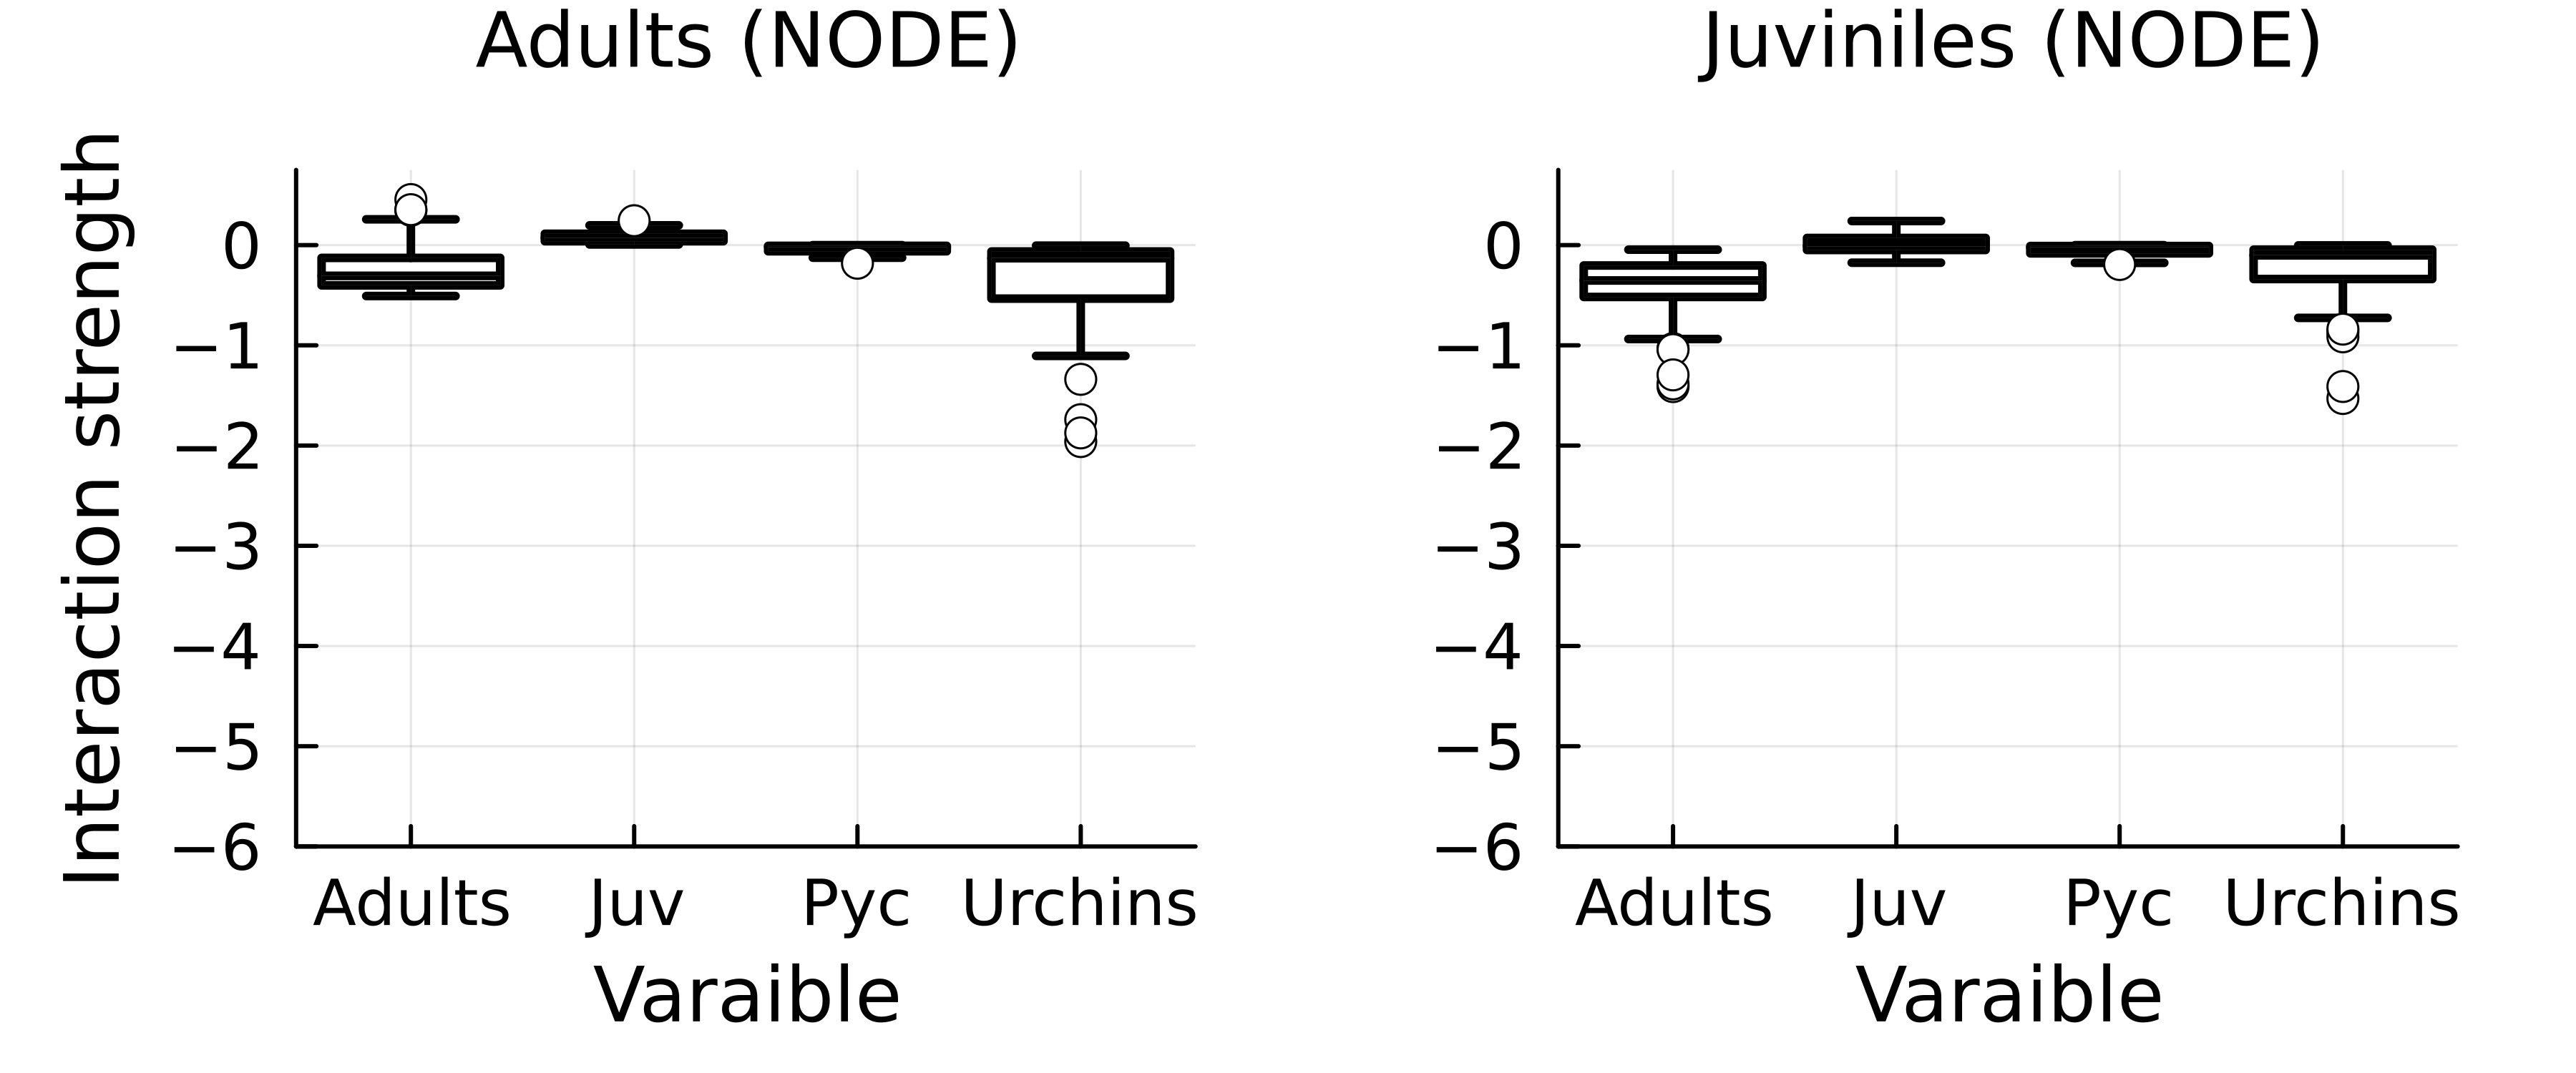

In [137]:
p3

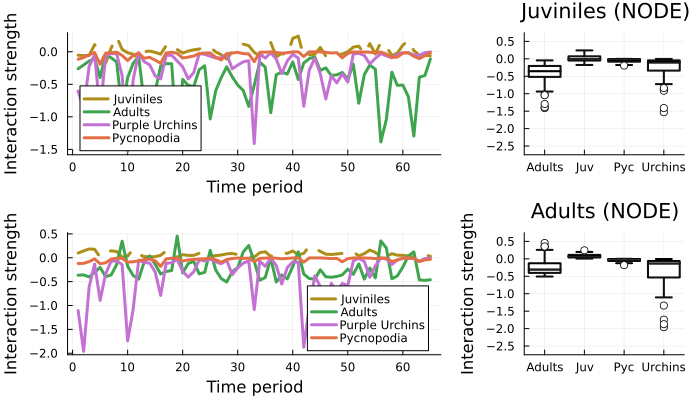

In [ ]:
l = @layout [a b{0.3w} ; c d{0.3w}]
Plots.plot(p1,p2_,p2,p1_,layout = l, size = (700,400),margin=2mm,dpi=600)